In [11]:
pip install scipy 

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
import pandas as pd
import scipy.stats as stats

# 1. Load the dataset
df = pd.read_csv("supermarket_sales.csv")

# 2. Display first five records
print("First Five Records:")
print(df.head())

# 3. Select the revenue column
revenue = df["revenue"]

# 4. Check for missing values
print("\nMissing Values in Revenue:", revenue.isnull().sum())

# 5. Calculate mean revenue
mean_revenue = revenue.mean()
print("Mean Revenue:", round(mean_revenue, 2))

# 6. Expected average revenue
expected_revenue = 1500

# 7. Null Hypothesis
print("\nH0: μ = 1500")

# 8. Alternative Hypothesis
print("H1: μ ≠ 1500")

# 9. Significance level
alpha = 0.05

# 10. Perform one-sample t-test
t_stat, p_value = stats.ttest_1samp(revenue, expected_revenue)

# 11. Display p-value
print("\nT-statistic:", round(t_stat, 2))
print("P-value:", p_value)

# 12 & 13. Compare p-value with 0.05
if p_value < alpha:
    print("Result: Reject H0")
else:
    print("Result: Do not reject H0")

# 14. Business conclusion
print("\nConclusion:")
if p_value < alpha:
    print("The average revenue is significantly different from ₹1500.")
else:
    print("There is not enough evidence to conclude that average revenue differs from ₹1500.")

print("\nPriti Yadav T054")

First Five Records:
    invoice_id branch       city customer_type gender_customer  \
0  750-67-8428      A     Yangon        Member          Female   
1  226-31-3081      C  Naypyitaw        Normal          Female   
2  631-41-3108      A     Yangon        Normal            Male   
3  123-19-1176      A     Yangon        Member            Male   
4  373-73-7910      A     Yangon        Normal            Male   

             product_line  unit_cost  quantity  5pct_markup   revenue  \
0       Health and beauty      74.69         7      26.1415  548.9715   
1  Electronic accessories      15.28         5       3.8200   80.2200   
2      Home and lifestyle      46.33         7      16.2155  340.5255   
3       Health and beauty      58.22         8      23.2880  489.0480   
4       Sports and travel      86.31         7      30.2085  634.3785   

        date   time payment_method    cogs    gm_pct  gross_income  rating  
0   01/05/19  13:08        Ewallet  522.83  4.761905       26.1415 

A/B Testing Data:
  Group  Users  Conversions
0     A   1000          120
1     B   1000          150

Group A Conversion Rate: 12.0 %
Group B Conversion Rate: 15.0 %

Difference in Conversion Rate: 3.0 %

H0: pA = pB
H1: pA ≠ pB

Z-statistic: -1.963
P-value: 0.04964
Result: Reject H0


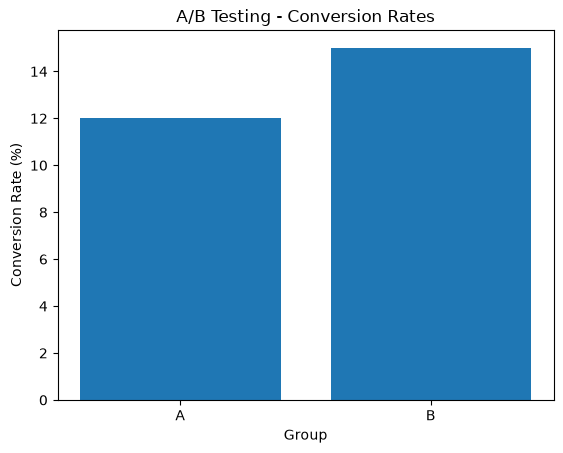


Conclusion:
There is a statistically significant difference in conversion rates between Group A and Group B.

Priti Yadav T054


In [8]:
import pandas as pd
import numpy as np
from statsmodels.stats.proportion import proportions_ztest
import matplotlib.pyplot as plt

# 1. Load the A/B testing dataset
df = pd.read_csv("ab_testing.csv")

# 2. Display the data
print("A/B Testing Data:")
print(df)

# 3. Calculate conversion rate for Group A
group_a = df[df["Group"] == "A"].iloc[0]

users_a = group_a["Users"]
conversions_a = group_a["Conversions"]

conversion_rate_a = conversions_a / users_a

print("\nGroup A Conversion Rate:",
      round(conversion_rate_a * 100, 2), "%")

# 4. Calculate conversion rate for Group B
group_b = df[df["Group"] == "B"].iloc[0]

users_b = group_b["Users"]
conversions_b = group_b["Conversions"]

conversion_rate_b = conversions_b / users_b

print("Group B Conversion Rate:",
      round(conversion_rate_b * 100, 2), "%")

# 5. Compare conversion rates
print("\nDifference in Conversion Rate:",
      round((conversion_rate_b - conversion_rate_a) * 100, 2), "%")

# 6. Null Hypothesis
print("\nH0: pA = pB")

# 7. Alternative Hypothesis
print("H1: pA ≠ pB")

# 8. Significance level
alpha = 0.05

# 9. Perform two-proportion test
successes = np.array([conversions_a, conversions_b])
observations = np.array([users_a, users_b])

z_stat, p_value = proportions_ztest(
    successes,
    observations
)

# 10. Display p-value
print("\nZ-statistic:", round(z_stat, 3))
print("P-value:", round(p_value, 5))

# 11 & 12. Compare p-value with 0.05
if p_value < alpha:
    print("Result: Reject H0")
else:
    print("Result: Do not reject H0")

# 13. Bar chart
groups = ["A", "B"]
conversion_rates = [
    conversion_rate_a * 100,
    conversion_rate_b * 100
]

plt.bar(groups, conversion_rates)
plt.xlabel("Group")
plt.ylabel("Conversion Rate (%)")
plt.title("A/B Testing - Conversion Rates")
plt.show()

# 14. Conclusion
print("\nConclusion:")
if p_value < alpha:
    print("There is a statistically significant difference in conversion rates between Group A and Group B.")
else:
    print("There is no statistically significant difference in conversion rates between Group A and Group B.")

print("\nPriti Yadav T054")